# Classificação climática de Thornthwaite (1948) — CHELSA V2.1, normal 1991-2020

Versão em Python do script JS anterior (TerraClimate, amostragem por município), agora **pixel a pixel na
grade nativa do CHELSA (~928 m)**, no mesmo padrão dos notebooks de Holdridge e Köppen. Metodologia:
Tabelas 1-5 de Aparecido et al. (2016).

- **ETP:** Penman-Monteith (`pet` do CHELSA), como em Aparecido et al. (2016).
- **Balanço hídrico:** Thornthwaite & Mather (1955), pela função vetorizada
  `balanco_hidrico_climatologico_grade` da biblioteca `agrometeorologiapy` (>= 0.2.0), com armazenamento
  inicial de equilíbrio do ciclo anual. O excedente (EXC) e a deficiência (DEF) saem do BHC — o script JS
  usava o escoamento (`ro`) e o déficit (`def`) do TerraClimate.
- **CAD, duas versões:** fixa em 100 mm (padrão clássico dos zoneamentos) e pelo solo, CAD = AWC x 1000 x z,
  com z = 1 m (asset `AWC_br`, AWC em m³/m³). Corpos d'água ficam sem dado; afloramentos de rocha recebem o
  menor AWC do asset (25 mm).

**Correções em relação ao script JS** (detalhes em [thornthwaite.py](thornthwaite.py)): limite 855 (não 885)
na Tabela 4; subtipos s/w dos climas secos estavam invertidos; concentração estival com o verão de 3 meses
da Tabela 1 (não out-mar); inverno com 1/3 de junho (não 2/3); verão e inverno trocados no hemisfério norte.

O cálculo é local (numpy): o GEE só é usado para rasterizar o AWC. Nada é exportado para o GEE/Drive.

## 1. Configuração

In [1]:
import sys
sys.path.insert(0, ".")
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

import agrometeorologiapy as amp
import thornthwaite as th

print("agrometeorologiapy", amp.__version__)
assert tuple(int(x) for x in amp.__version__.split(".")[:2]) >= (0, 2), \
    "precisa da agrometeorologiapy >= 0.2.0 (balanco_hidrico_climatologico_grade)"

PROJETO = "fcoliveira"
ASSET_AWC = "projects/fcoliveira/assets/AWC_br"

DIR_NORMAL = Path("../dados_chelsa/normal_1991_2020")
ARQ_PET = DIR_NORMAL / "chelsa_brasil_pet_normal_1991_2020.tif"
ARQ_PR = DIR_NORMAL / "chelsa_brasil_pr_normal_1991_2020.tif"

DIR_AWC = Path("../dados_chelsa/awc")
ARQ_AWC = DIR_AWC / "AWC_BR_grade_CHELSA.tif"

DIR_SAIDA = Path("../dados_chelsa/thornthwaite")
CAD_FIXA = 100.0       # mm
Z_RAIZ = 1.0           # m; CAD do solo = AWC (mm/m) x Z_RAIZ
VERSOES = {"CAD100": DIR_SAIDA / "Thornthwaite_CHELSA_BR_1991_2020_CAD100.tif",
           "CADsolo": DIR_SAIDA / "Thornthwaite_CHELSA_BR_1991_2020_CADsolo.tif"}

agrometeorologiapy 0.2.0


## 2. AWC na grade do CHELSA (GEE)

`AWC_br` é uma tabela de polígonos de solo (não uma imagem). A célula abaixo a rasteriza no GEE exatamente
na grade das normais locais (mesma origem, resolução e tamanho) e baixa um GeoTIFF de 2 bandas:
`awc_mm_m` (AWC x 1000, mm de água por metro de solo) e `brasil` (máscara do país, FAO GAUL). Só roda se o
arquivo ainda não existir.

In [2]:
if not ARQ_AWC.exists():
    import ee
    import geemap
    try:
        ee.Initialize(project=PROJETO)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=PROJETO)
    brasil = (ee.FeatureCollection("FAO/GAUL/2015/level0")
              .filter(ee.Filter.eq("ADM0_NAME", "Brazil")))
    with rasterio.open(ARQ_PET) as ref:
        t, forma = ref.transform, (ref.height, ref.width)
    DIR_AWC.mkdir(parents=True, exist_ok=True)
    geemap.download_ee_image(
        th.awc_imagem(ASSET_AWC, brasil),
        filename=str(ARQ_AWC),
        crs="EPSG:4326",
        crs_transform=[t.a, t.b, t.c, t.d, t.e, t.f],
        shape=forma,
        dtype="float32",
        max_tile_size=4,   # tiles pequenos: evita "User memory limit exceeded" no GEE
    )

with rasterio.open(ARQ_AWC) as r:
    awc_mm_m = r.read(1, masked=True).filled(np.nan)
    mascara_br = r.read(2) == 1
    transform = r.transform

cad_solo = awc_mm_m * Z_RAIZ
print(f"Pixels no Brasil: {mascara_br.sum():,}")
print(f"  sem AWC (corpos d'água / borda): {(mascara_br & np.isnan(cad_solo)).sum():,}")
v = cad_solo[mascara_br & np.isfinite(cad_solo)]
print(f"CAD do solo (mm): min {v.min():.0f} | p25 {np.percentile(v, 25):.0f} | mediana {np.median(v):.0f} "
      f"| p75 {np.percentile(v, 75):.0f} | max {v.max():.0f}")

/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_3149/949086993.py:26: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  mascara_br = r.read(2) == 1


Pixels no Brasil: 10,197,584
  sem AWC (corpos d'água / borda): 170,990
CAD do solo (mm): min 25 | p25 94 | mediana 116 | p75 127 | max 209


## 3. Balanço hídrico e classificação

Para cada versão de CAD: BHC pixel a pixel e Tabelas 2-5. O raster é processado em faixas de linhas (a grade
inteira não cabe na memória). Saída: GeoTIFF de 10 bandas — códigos `umidade`, `subtipo`, `termica`,
`concentracao` e as variáveis `pety`, `def_anual`, `exc_anual` (mm/ano), `ih`, `ia`, `im`. Leva ~1,5 min por
versão.

In [3]:
DIR_SAIDA.mkdir(parents=True, exist_ok=True)
cads = {"CAD100": CAD_FIXA, "CADsolo": cad_solo}
for nome, arq in VERSOES.items():
    th.processar_raster(ARQ_PET, ARQ_PR, cads[nome], mascara_br, arq)
    print(f"{nome}: {arq.resolve()}")

CAD100: /Users/coted-sh/Python/MapBiomas_analises/climas/dados_chelsa/thornthwaite/Thornthwaite_CHELSA_BR_1991_2020_CAD100.tif
CADsolo: /Users/coted-sh/Python/MapBiomas_analises/climas/dados_chelsa/thornthwaite/Thornthwaite_CHELSA_BR_1991_2020_CADsolo.tif


In [4]:
def ler(arq):
    with rasterio.open(arq) as r:
        return {nome: r.read(i + 1) for i, nome in enumerate(th.BANDAS_SAIDA)}

RES = {nome: ler(arq) for nome, arq in VERSOES.items()}

# Peso de área de cada pixel (grade em graus: a área cai com cos(lat)).
linhas = np.arange(mascara_br.shape[0]) + 0.5
lat_lin = transform.f + transform.e * linhas
PESO = np.broadcast_to(np.cos(np.radians(lat_lin))[:, None], mascara_br.shape)

/var/folders/50/s8hjm0h134j6vnljh7hmbhqc0000gn/T/ipykernel_3149/1888901531.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  return {nome: r.read(i + 1) for i, nome in enumerate(th.BANDAS_SAIDA)}


## 4. Verificação: área por classe

Porcentagem da área classificada de cada versão, por componente do tipo climático.

In [5]:
COMPONENTES = {"umidade": th.LEG_UMIDADE, "subtipo": th.LEG_SUBTIPO,
               "termica": th.LEG_TERMICA, "concentracao": th.LEG_CONCENTRACAO}

def area_por_classe(res, comp):
    b = res[comp]
    ok = np.isfinite(b)
    cods = b[ok].astype(int)
    pesos = PESO[ok]
    tot = np.bincount(cods, weights=pesos)
    s = pd.Series(100 * tot / pesos.sum()).loc[lambda x: x > 0]
    return s

for comp, leg in COMPONENTES.items():
    tab = pd.DataFrame({nome: area_por_classe(res, comp) for nome, res in RES.items()}).fillna(0)
    tab.index = [f"{i} {leg[i]}" for i in tab.index]
    tab.index.name = comp
    display(tab.round(1))

,CAD100,CADsolo
umidade,,
1 A,4.4,4.4
2 B4,4.5,4.5
3 B3,10.7,10.6
4 B2,15.7,15.7
5 B1,15.0,15.0
6 C2,16.1,16.2
7 C1,17.6,17.8
8 D,12.5,12.5
9 E,3.5,3.4


,CAD100,CADsolo
subtipo,,
1 r,32.9,34.3
2 s,2.3,2.2
3 w,26.0,25.1
4 s2,0.0,0.0
5 w2,5.3,4.7
6 d,26.1,26.1
7 s,0.2,0.3
8 w,6.0,6.1
9 s2,0.0,0.0


,CAD100,CADsolo
termica,,
1 A',99.5,99.5
2 B4',0.5,0.5
3 B3',0.0,0.0


,CAD100,CADsolo
concentracao,,
1 a',100.0,100.0


## 5. Pontos de referência

Tipo climático e variáveis anuais em algumas cidades, nas duas versões de CAD.

In [6]:
CIDADES = {"Belém": (-48.49, -1.46), "Manaus": (-60.02, -3.12), "Boa Vista": (-60.67, 2.82),
           "Fortaleza": (-38.54, -3.73), "Petrolina": (-40.50, -9.39), "Cuiabá": (-56.10, -15.60),
           "Brasília": (-47.88, -15.79), "Londrina": (-51.16, -23.31), "Curitiba": (-49.27, -25.43),
           "São Joaquim": (-49.93, -28.29), "Porto Alegre": (-51.22, -30.03), "Uruguaiana": (-57.09, -29.76)}

linhas_tab = []
for nome_v, arq in VERSOES.items():
    with rasterio.open(arq) as r:
        for cidade, xy in CIDADES.items():
            v = next(r.sample([xy]))
            cods = [int(x) if np.isfinite(x) else 0 for x in v[:4]]
            linhas_tab.append({"cidade": cidade, "versao": nome_v, "tipo": th.codigo_completo(*cods),
                               "PETY": v[4], "DEF": v[5], "EXC": v[6], "Im": v[9]})
pontos = (pd.DataFrame(linhas_tab)
          .pivot(index="cidade", columns="versao", values=["tipo", "DEF", "EXC", "Im"])
          .reindex(CIDADES.keys()))
with rasterio.open(ARQ_AWC) as r:
    pontos[("CAD solo (mm)", "")] = [next(r.sample([xy]))[0] * Z_RAIZ for xy in CIDADES.values()]
display(pontos.round(1))

tipo                    DEF                       EXC  \
versao          CAD100   CADsolo       CAD100      CADsolo       CAD100   
cidade                                                                    
Belém          B3rA'a'   B3rA'a'   138.768539   134.712708  1261.804077   
Manaus         B3rA'a'   B3rA'a'    73.554176    59.371998  1018.110413   
Boa Vista     C2w2A'a'  C2w2A'a'   661.190491   653.667236   484.956421   
Fortaleza      C1wA'a'   C1wA'a'   837.276306   850.864258   245.701508   
Petrolina       EdA'a'    EdA'a'  1405.802856  1405.802856          0.0   
Cuiabá         C1wA'a'   C1wA'a'   411.281128   430.107788   188.286606   
Brasília       C1wA'a'   C1wA'a'   434.961243   410.880463   247.700714   
Londrina       C2rA'a'   C2rA'a'    18.862404     23.93203   206.955139   
Curitiba      B1rB4'a'  B1rB4'a'     0.607156     0.475864   295.756958   
São Joaquim    B2rA'a'   B2rA'a'          0.0          0.0   662.870361   
Porto Alegre   C2rA'a'   C2rA'a'   165.638977   195.797348   238.430481   
Uruguaiana     C2rA'a'   C2rA'a'    54.528706    45.821823   127.281242   

                                  Im            CAD solo (mm)  
versao            CADsolo     CAD100    CADsolo                
cidade                                                         
Belém         1257.748291  69.319351   69.22393    106.199997  
Manaus        1003.928223  71.764984  71.346992    138.800003  
Boa Vista      477.433167   5.156435   4.980587    107.599998  
Fortaleza      259.289429  -13.98252 -13.686424     86.400002  
Petrolina             0.0 -46.707787 -46.707787    174.600006  
Cuiabá         207.113266  -3.672203  -3.199337     80.699997  
Brasília       223.619919  -0.883796  -1.525027    125.400002  
Londrina       212.024765  13.698771  13.840763     73.900002  
Curitiba       295.625671  26.193869  26.189213    128.300003  
São Joaquim    662.870361  57.689575  57.689575    129.699997  
Porto Alegre   268.588837  10.897888   11.84336     63.299999  
Uruguaiana     118.574356   6.867823   6.614883    127.699997

## 6. Mapas

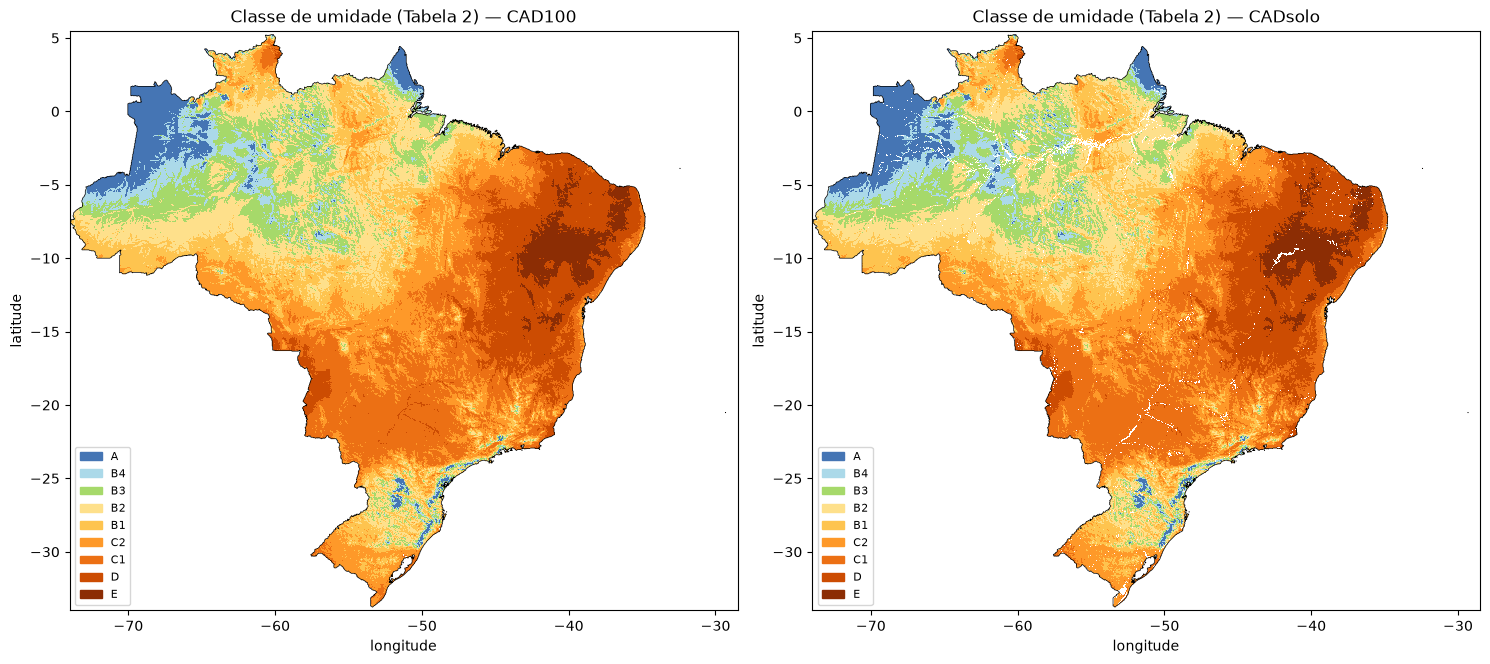

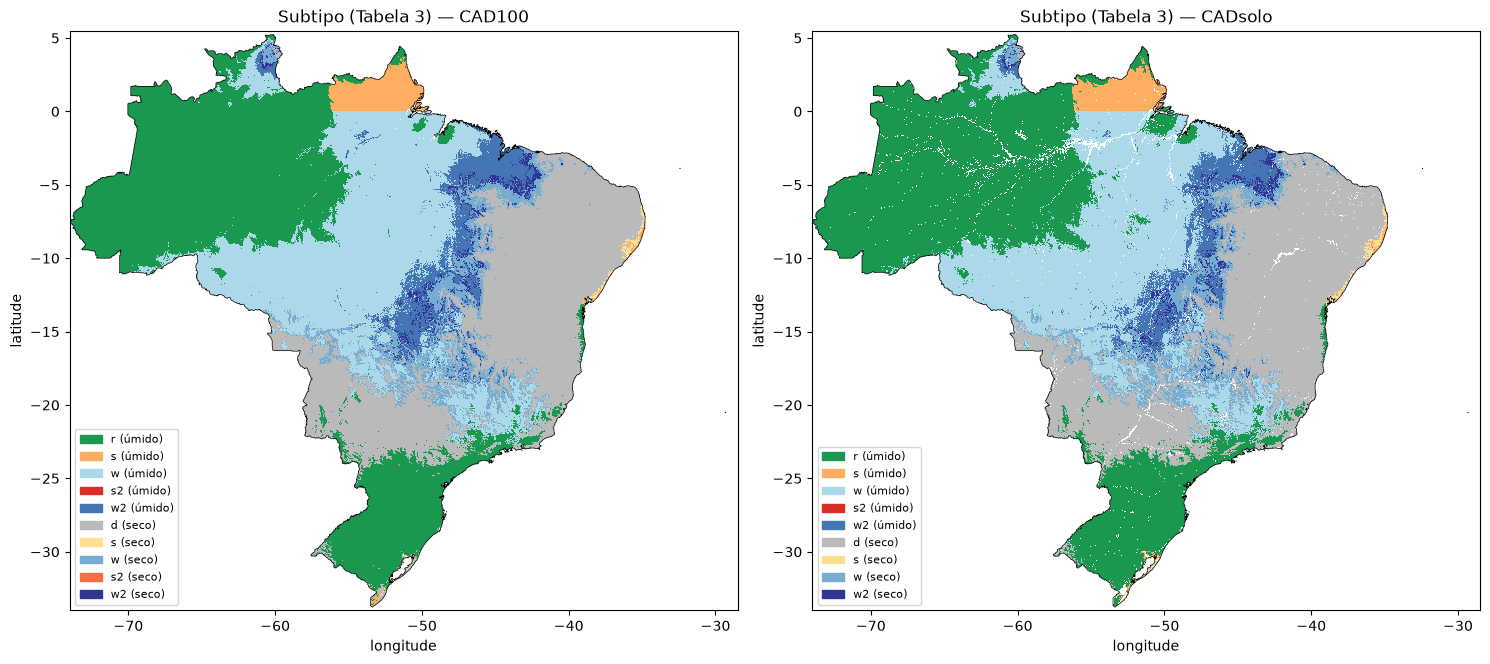

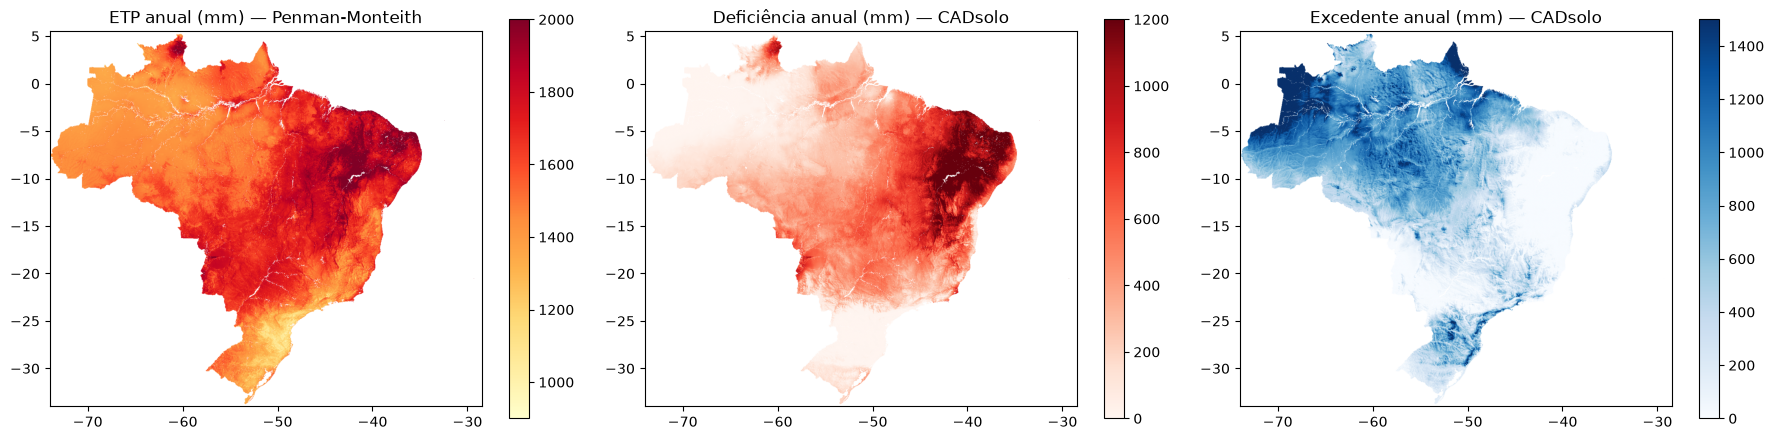

In [7]:
PASSO = 4  # subamostragem só para desenhar mais rápido
ext = [transform.c, transform.c + transform.a * mascara_br.shape[1],
       transform.f + transform.e * mascara_br.shape[0], transform.f]

def mapa_categorico(ax, banda, leg, cores, titulo):
    b = banda[::PASSO, ::PASSO]
    presentes = sorted(int(x) for x in np.unique(b[np.isfinite(b)]))
    cmap = ListedColormap(cores)
    norm = BoundaryNorm(np.arange(0.5, len(cores) + 1.5), cmap.N)
    ax.imshow(np.ma.masked_invalid(b), cmap=cmap, norm=norm, extent=ext, interpolation="nearest")
    ax.contour(mascara_br[::PASSO, ::PASSO], levels=[0.5], colors="k", linewidths=0.5,
               extent=ext, origin="upper")
    ax.set_title(titulo)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.legend(handles=[mpatches.Patch(color=cores[k - 1], label=leg[k]) for k in presentes],
              loc="lower left", fontsize=8, frameon=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
for ax, (nome, res) in zip(axes, RES.items()):
    mapa_categorico(ax, res["umidade"], th.LEG_UMIDADE, th.PALETA_UMIDADE,
                    f"Classe de umidade (Tabela 2) — {nome}")
plt.tight_layout(); plt.show()

CORES_SUBTIPO = ["#1a9850", "#fdae61", "#abd9e9", "#d73027", "#4575b4",
                 "#bababa", "#fee090", "#74add1", "#f46d43", "#313695"]
LEG_SUBTIPO_MAPA = {k: (f"{v} (úmido)" if k <= 5 else f"{v} (seco)") for k, v in th.LEG_SUBTIPO.items()}
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
for ax, (nome, res) in zip(axes, RES.items()):
    mapa_categorico(ax, res["subtipo"], LEG_SUBTIPO_MAPA, CORES_SUBTIPO,
                    f"Subtipo (Tabela 3) — {nome}")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (var, titulo, cmap, lim) in zip(axes, [
        ("pety", "ETP anual (mm) — Penman-Monteith", "YlOrRd", (900, 2000)),
        ("def_anual", "Deficiência anual (mm) — CADsolo", "Reds", (0, 1200)),
        ("exc_anual", "Excedente anual (mm) — CADsolo", "Blues", (0, 1500))]):
    b = RES["CADsolo"][var][::PASSO, ::PASSO]
    im = ax.imshow(np.ma.masked_invalid(b), cmap=cmap, vmin=lim[0], vmax=lim[1], extent=ext)
    ax.set_title(titulo); fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

## 7. Comparação CAD 100 mm x CAD do solo

Tabela cruzada da classe de umidade (% da área onde as duas versões têm dado) e mapa dos pixels que mudam de
classe. A CAD do solo é, em mediana, ~116 mm: onde ela é maior que 100 mm o solo guarda mais água, o que
reduz tanto a deficiência quanto o excedente.

,A,B4,B3,B2,B1,C2,C1,D,E
A,4.38,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
B4,0.00,4.48,0.07,0.00,0.00,0.00,0.00,0.00,0.00
B3,0.00,0.01,10.47,0.28,0.00,0.00,0.00,0.00,0.00
B2,0.00,0.00,0.02,15.33,0.28,0.00,0.00,0.00,0.00
B1,0.00,0.00,0.00,0.08,14.58,0.23,0.00,0.00,0.00
C2,0.00,0.00,0.00,0.00,0.10,15.78,0.26,0.00,0.00
C1,0.00,0.00,0.00,0.00,0.00,0.19,17.39,0.09,0.00
D,0.00,0.00,0.00,0.00,0.00,0.00,0.15,12.37,0.00
E,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.44


Mesma classe de umidade em 98.2% da área.
Mesmo subtipo: 94.7% da área.
Mesmo termica: 100.0% da área.
Mesmo concentracao: 100.0% da área.


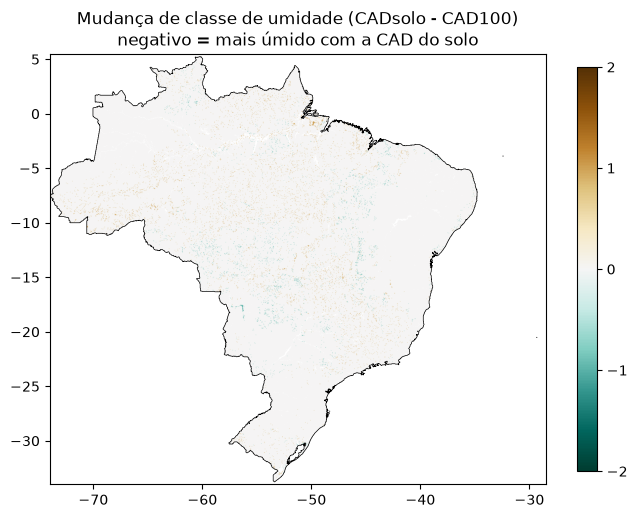

In [8]:
u100, usolo = RES["CAD100"]["umidade"], RES["CADsolo"]["umidade"]
ambos = np.isfinite(u100) & np.isfinite(usolo)
cruz = pd.crosstab(pd.Series(u100[ambos].astype(int), name="CAD100"),
                   pd.Series(usolo[ambos].astype(int), name="CADsolo"),
                   values=PESO[ambos], aggfunc="sum", normalize=True) * 100
cruz.index = [th.LEG_UMIDADE[i] for i in cruz.index]
cruz.columns = [th.LEG_UMIDADE[i] for i in cruz.columns]
display(cruz.round(2))

igual = np.average(u100[ambos] == usolo[ambos], weights=PESO[ambos]) * 100
print(f"Mesma classe de umidade em {igual:.1f}% da área.")
for comp in ("subtipo", "termica", "concentracao"):
    a, b = RES["CAD100"][comp], RES["CADsolo"][comp]
    ok = np.isfinite(a) & np.isfinite(b)
    print(f"Mesmo {comp}: {np.average(a[ok] == b[ok], weights=PESO[ok]) * 100:.1f}% da área.")

dif = np.where(ambos, usolo - u100, np.nan)[::PASSO, ::PASSO]
fig, ax = plt.subplots(figsize=(8, 7.5))
im = ax.imshow(np.ma.masked_invalid(dif), cmap="BrBG_r", vmin=-2, vmax=2, extent=ext)
ax.contour(mascara_br[::PASSO, ::PASSO], levels=[0.5], colors="k", linewidths=0.5, extent=ext, origin="upper")
ax.set_title("Mudança de classe de umidade (CADsolo - CAD100)\nnegativo = mais úmido com a CAD do solo")
fig.colorbar(im, ax=ax, shrink=0.7, ticks=[-2, -1, 0, 1, 2])
plt.show()

## 8. Tipos climáticos completos

Os tipos (4 letras) mais frequentes em cada versão.

In [9]:
def tipos(res):
    u, s, t, c = (res[k] for k in ("umidade", "subtipo", "termica", "concentracao"))
    ok = np.isfinite(u) & np.isfinite(s) & np.isfinite(t) & np.isfinite(c)
    chave = (u[ok].astype(np.int64) * 10000 + s[ok].astype(np.int64) * 100
             + t[ok].astype(np.int64) * 10 + c[ok].astype(np.int64))
    uniq, inv = np.unique(chave, return_inverse=True)
    area = np.bincount(inv, weights=PESO[ok])
    nomes = [th.codigo_completo(k // 10000, k // 100 % 100, k // 10 % 10, k % 10) for k in uniq]
    return pd.Series(100 * area / area.sum(), index=nomes).sort_values(ascending=False)

tab_tipos = pd.DataFrame({nome: tipos(res) for nome, res in RES.items()}).fillna(0)
tab_tipos = tab_tipos.sort_values("CADsolo", ascending=False)
print(f"{len(tab_tipos)} tipos distintos")
display(tab_tipos.head(15).round(1))

41 tipos distintos


,CAD100,CADsolo
DdA'a',12.4,12.4
C1dA'a',10.2,10.3
B2rA'a',8.4,9.0
B1wA'a',9.2,8.9
B3rA'a',8.5,8.8
C2wA'a',8.4,8.7
B2wA'a',6.6,6.1
C1wA'a',5.9,6.0
B1rA'a',4.5,4.9
C2w2A'a',4.7,4.3


## 9. Observação sobre a ETP de Penman-Monteith

Os limites das Tabelas 4 e 5 (eficiência térmica e concentração estival) foram definidos por Thornthwaite
(1948) com a **sua** ETP, calculada da temperatura. A ETP de Penman-Monteith do CHELSA é, no Brasil, alta o
bastante para que quase todo o país passe de 1140 mm/ano (A', megatérmico) e tenha menos de 48% da ETP no
verão (a'). Isso é coerente com Aparecido et al. (2016), que também usaram Penman-Monteith e encontraram
A'a' predominante no Paraná, mas faz com que as duas últimas letras quase não diferenciem regiões: a
variação está na classe de umidade e no subtipo.